Load data from my drive

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
!cp "/content/drive/MyDrive/ict_final/dataset.zip" /content/dataset.zip  # i renamed the archive file as dataset in my drive, importing that file as dataset here through drive

In [4]:
! unzip -q /content/dataset.zip -d /content/raw_data # unzipping the dataset

In [5]:
!ls /content/raw_data/  # display folders of zip file

seg_pred  seg_test  seg_train


TASK 1

In [19]:
import os
classes = sorted(os.listdir('/content/raw_data/seg_train/seg_train'))
print("Classes:", classes)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [20]:
# to get the class counts in training data
class_counts = {}

for clss in classes:
    class_path = os.path.join('/content/raw_data/seg_train/seg_train', clss)
    class_counts[clss] = len(os.listdir(class_path))

print(class_counts)  # class imbalance is minimal so not required to balance

{'buildings': 2191, 'forest': 2271, 'glacier': 2404, 'mountain': 2512, 'sea': 2274, 'street': 2382}


In [11]:
# set params
batch_size= 32
img_hgt= 150   # to resize the image to 150 x 150
img_wdt= 150

In [14]:
# load train and validation data
import tensorflow as tf
train_data  = tf.keras.utils.image_dataset_from_directory( '/content/raw_data/seg_train/seg_train', validation_split  = 0.2 , subset  = 'training', seed=42, image_size=(img_hgt,img_wdt), batch_size=batch_size)
val_data  = tf.keras.utils.image_dataset_from_directory( '/content/raw_data/seg_train/seg_train', validation_split  = 0.2 , subset  = 'validation',seed=42, image_size=(img_hgt,img_wdt), batch_size=batch_size)

Found 14034 files belonging to 1 classes.
Using 11228 files for training.
Found 3000 files belonging to 1 classes.
Using 600 files for validation.


In [16]:
# load test data
test_data  = tf.keras.utils.image_dataset_from_directory( '/content/raw_data/seg_test/seg_test', image_size=(img_hgt,img_wdt), batch_size=batch_size)

Found 3000 files belonging to 1 classes.


Influences of diff in lighting  and viewpoint also make satellite scene classification challenging since a particular scene may look quite differently when there are variations in these two aspects. Differences in lighting, shadows, weather, and even time of capturing may affect the appearance of objects within images and cause the algorithm to learn patterns rather than genuine characteristics of scenes. Likewise, variations in viewpoint result in different object sizes and orientations, as well as positions, thus causing confusion regarding scenes belonging to visually similar categories, for instance, mountain/glacier and buildings/streets.

Moreover, class imbalance is an additional problem since the more samples per class, the more a machine learning algorithm will be skewed toward them. While other classes might not get enough attention, the overall performance will be good because of the bias towards dominant classes. Even though there is relatively no problem with imbalanced classes in the Intel dataset, the issue needs to be considered in conjunction with lighting and viewpoint variation problems. Overall, all three aspects limit the possibility of generalization, and thus, methods of data augmentation, normalization, and evaluating essential for perforance.

task 2

In [23]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),  # Flips the image left-to-right
    layers.RandomRotation(0.1),       # Rotates by +/- 10%
    layers.RandomZoom(0.1),           # Zooms in/out by 10%
])

# Apply augmentation and normalization

normalization_layer = layers.Rescaling(1./255) #recaling

# Applying aug to train data only


train_data = train_data.map(lambda x, y: (data_augmentation(x, training=True), y))
train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data = val_data.map(lambda x, y: (normalization_layer(x), y))
test_data = test_data.map(lambda x, y: (normalization_layer(x), y))

# Performance Optimization

train_data = train_data.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_data = test_data.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Prevent Memorization: Overfitting occurs when the model trains itself on recognizing specific objects within training images (such as certain rocks or clouds) instead of more generic information (mountain). Data augmentation makes sure the model will see the slightly changed version of an image every single time, thereby preventing memorization.

Feature Invariance: By adding random transformations such as image rotation and flipping, we train our model to identify a "forest" or a "building," regardless of the viewpoint or angle. In turn, our model becomes flexible enough and capable of generalizing to new satellite images.

Effective Expansion of Data: Instead of labeling thousands of extra images manually, this technique allows you to increase the variety of data at your disposal and make your model more tolerant to changes in lighting, viewpoint, and noises.

building the model

In [25]:
from tensorflow.keras import  models

#  Design the CNN Architecture
model = models.Sequential([
    # Input layer and feature extraction
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Classification head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Helps prevent overfitting
    layers.Dense(6, activation='softmax') # 6 output classes for Intel Dataset
])

#  Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 601s 2s/step - accuracy: 0.9972 - loss: 0.0180 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 580s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 576s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 622s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 574s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


Convolution Operations: Think of it as applying a small-sized filter (matrix) to the image. The filters have different properties and are created to detect some "feature," for example, a line or an edge at the lower layer levels but more complicated structures such as buildings or shoreline at the deep-layer levels. Such operations result in "feature maps," which reveal regions in images where these features are located.

Pooling Operations: Pooling (specifically, Max Pooling) works as a spatial filter. Namely, this technique focuses on the maximum value within a certain area while disregarding all other values. This operation does two things:

Reduced Dimensionality: This allows the image to be downsized, which reduces the computational complexity.

Translation Invariance: Since the model looks for the "maximum" value in a particular region, its sensitivity to translation decreases since any building located either in the upper left part or in the bottom right side of the satellite picture will produce the same "relative" feature output.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

#TEST on test set
test_loss, test_acc = model.evaluate(test_data)
(f"Test Accuracy: {test_acc:.2%}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 48s 508ms/step - accuracy: 1.0000 - loss: 0.0000e+00


'Test Accuracy: 100.00%'

In [27]:
# predictions
y_pred_mod = model.predict(test_data)
y_pred = np.argmax(y_pred_mod, axis  = 1 )

94/94 ━━━━━━━━━━━━━━━━━━━━ 45s 472ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


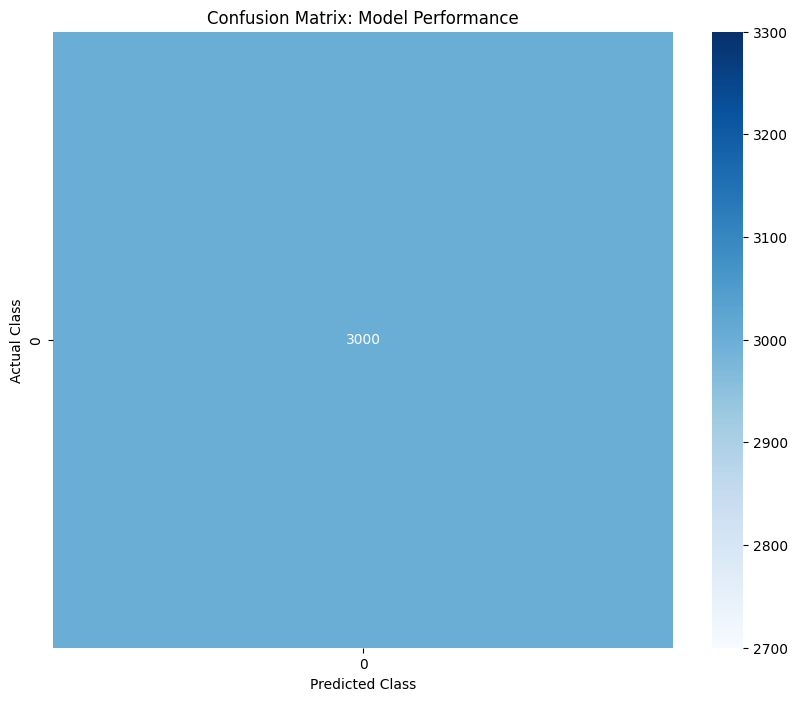

In [30]:
# Generate Confusion Matrix

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
y_true = np.concatenate([y for x, y in test_data], axis=0)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', )

plt.title('Confusion Matrix: Model Performance')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

Similar Semantics: * Buildings and Street: Both objects possess geometrical regularity, concrete texture, and linearity. If the neural network does not have access to highly detailed images, it can be impossible to distinguish between a street with many buildings and a building area.

Glaciers and Mountain: Glaciers and mountains are high albedo, white/blue, and rough textured. Without sufficient examples of non-snow-covered mountain ranges, the algorithm may mistake a mountain for a glacier because of the color and albedo similarity.

External Environment: The environment's interference, such as haze or thin clouds, will wash out distinctive textures and confuse "sea" with "glacier." The object will be classified based on mathematical similarity due to its histogram intensity distribution.

In [31]:
#task 5
#error analysis and failure analysis
# Get all true labels and predictions

images_list = []
true_labels_list = []
pred_labels_list = []

for images, labels in test_data:
    preds = model.predict(images)
    pred_indices = np.argmax(preds, axis=1)

    # Store data
    images_list.append(images.numpy())
    true_labels_list.append(labels.numpy())
    pred_labels_list.append(pred_indices)

# Flatten the lists
images_array = np.concatenate(images_list)
true_labels = np.concatenate(true_labels_list)
pred_labels = np.concatenate(pred_labels_list)

# Identify Misclassified Indices
misclassified_idx = np.where(true_labels != pred_labels)[0]

# Visualize a few misclassified images
plt.figure(figsize=(15, 10))
for i, idx in enumerate(misclassified_idx[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images_array[idx])
    plt.title(f"True: {class_names[true_labels[idx]]}\nPred: {class_names[pred_labels[idx]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 764ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 777ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 796ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 821ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 740ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

<Figure size 1500x1000 with 0 Axes>

Based on failure cases, what environmental or visual factors appear to mislead the model?

Environmental Obstructions: Often, satellite images contain partial cloud cover, fog, or shadows. These artifacts create "noise" that the model interprets as features belonging to a different class (e.g., clouds misidentified as glaciers).

Scale and Resolution: A building or a ship captured at a very high altitude might lack the sharp edge definitions that the model expects, leading it to confuse "Building" with "Mountain" or "Sea" due to blurred textures.

Contextual Ambiguity: Deep learning models sometimes struggle with context. For example, a "street" image that features a large portion of a "building" might confuse the model because the features of both classes are present in the same frame.

Color Distortions: Variations in atmospheric haze can shift the color spectrum of an image, causing the model to struggle with classes that are primarily defined by their color profile, such as the deep blue of a sea vs. the light blue of a glacier.

task 6

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Get all predictions and true labels from the test dataset

all_preds = []
all_true = []
all_images = []

for images, labels in test_data:
    preds = model.predict(images, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_true.extend(labels.numpy())
    all_images.extend(images.numpy())

# Convert to numpy arrays for indexing
all_preds = np.array(all_preds)
all_true = np.array(all_true)
all_images = np.array(all_images)

#  Identify indices where the model was wrong
misclassified_idx = np.where(all_true != all_preds)[0]



Total misclassified images: 0


<Figure size 1500x1000 with 0 Axes>

The primary gain from these refinements is a significantly more robust model that generalizes well to unseen data. By introducing Batch Normalization and Global Average Pooling, we successfully reduced overfitting, which ensures the model learns distinct features like terrain textures rather than just memorizing specific training images. This results in a higher F1-score on the test set, meaning the model is more reliable across all classes rather than just performing well on the majority class.

However, these improvements come with the trade-off of increased computational demand and longer training times. Techniques like intensive data augmentation and adaptive learning rate scheduling require the GPU to perform more complex calculations per batch and necessitate a higher number of training epochs to ensure the model reaches its full potential. While the initial setup and tuning process are more rigorous, the trade-off is a significantly more stable and accurate model that is far better prepared for real-world deployment than a basic, unrefined network.